

## Objetivo

Construir un único dataset a partir de tres fuentes:

- **Accidentes:** registros de accidentes por fecha y municipio.
- **Tráfico:** tráfico registrado en peajes por período mensual.
- **Taller:** servicios de reparación registrados por fecha.

El proceso sigue la misma estructura del proyecto anterior:

**Carga → diagnóstico → limpieza → preparación temporal → resumen → integración → transformación → escalamiento → reducción con PCA.**

> Importante: antes de integrar se comprobarán los períodos de cada fuente. Si no existe un período común, el notebook lo mostrará en lugar de inventar una relación temporal.


In [58]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.append("..")

from src.accidentes import Accidentes
from src.trafico import Trafico
from src.taller import Taller

pd.set_option("display.max_columns", None)


In [5]:
%pip install pandas numpy matplotlib


   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   ----- ---------------------------------- 1.3/9.6 MB 4.6 MB/s eta 0:00:02
   ----------- ---------------------------- 2.9/9.6 MB 5.6 MB/s eta 0:00:02
   ----------------- ---------------------- 4.2/9.6 MB 5.8 MB/s eta 0:00:01
   ---------------------- ----------------- 5.5/9.6 MB 6.0 MB/s eta 0:00:01
   ----------------------------- ---------- 7.1/9.6 MB 6.2 MB/s eta 0:00:01
   ---------------------------------- ----- 8.4/9.6 MB 6.3 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.6 MB 6.3 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 6.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Cargar los tres datasets

Cambia únicamente los nombres de los archivos por los nombres reales que tengas dentro de `dataset/`.

In [59]:
accidentes = Accidentes("../dataset/accidentes.csv")
trafico = Trafico("../dataset/trafico.csv")
taller = Taller("../dataset/taller.csv")

df_accidentes = accidentes.cargar()
df_trafico = trafico.cargar()
df_taller = taller.cargar()

print("Accidentes:", df_accidentes.shape)
print("Tráfico:", df_trafico.shape)
print("Taller:", df_taller.shape)


Accidentes: (633298, 6)
Tráfico: (149944, 9)
Taller: (2000000, 28)


## 2. Diagnóstico inicial

In [60]:
print("===== ACCIDENTES =====")
accidentes.diagnosticar()

print("\n===== TRÁFICO =====")
trafico.diagnosticar()

print("\n===== TALLER =====")
taller.diagnosticar()


===== ACCIDENTES =====
Dimensiones: (633298, 6)

Columnas:
['FECHA HECHO', 'COD_DEPTO', 'DEPARTAMENTO', 'COD_MUNI', 'MUNICIPIO', 'CANTIDAD']

Tipos de datos:
FECHA HECHO       str
COD_DEPTO       int64
DEPARTAMENTO      str
COD_MUNI        int64
MUNICIPIO         str
CANTIDAD        int64
dtype: object

Valores nulos:
FECHA HECHO     0
COD_DEPTO       0
DEPARTAMENTO    0
COD_MUNI        0
MUNICIPIO       0
CANTIDAD        0
dtype: int64

Duplicados: 287996

===== TRÁFICO =====
Dimensiones: (149944, 9)

Columnas:
['IdPeaje', 'Peaje', 'CategoriaTarifa', 'Desde', 'Hasta', 'ValorTarifa', 'CantidadTrafico', 'CantidadEvasores', 'CantidadExentos787']

Tipos de datos:
IdPeaje               int64
Peaje                   str
CategoriaTarifa         str
Desde                   str
Hasta                   str
ValorTarifa           int64
CantidadTrafico       int64
CantidadEvasores      int64
CantidadExentos787    int64
dtype: object

Valores nulos:
IdPeaje               0
Peaje                 0
C

## 3. Limpieza de los tres datasets

In [61]:
accidentes.limpiar()
trafico.limpiar()
taller.limpiar()

print("ACCIDENTES LIMPIOS")
display(accidentes.df.head())

print("TRÁFICO LIMPIO")
display(trafico.df.head())

print("TALLER LIMPIO")
display(taller.df.head())


c:\Users\Gilary Gacha\Downloads\proyecto_autogest\analisis\..\src\trafico.py:34: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  self.df["DESDE"] = pd.to_datetime(
c:\Users\Gilary Gacha\Downloads\proyecto_autogest\analisis\..\src\trafico.py:38: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  self.df["HASTA"] = pd.to_datetime(


ACCIDENTES LIMPIOS


,FECHA HECHO,COD_DEPTO,DEPARTAMENTO,COD_MUNI,MUNICIPIO,CANTIDAD
0,2026-07-31,5,ANTIOQUIA,5147,CAREPA,1
1,2026-07-31,76,VALLE DEL CAUCA,76147,CARTAGO,1
3,2026-07-31,76,VALLE DEL CAUCA,76248,EL CERRITO,1
5,2026-07-31,18,CAQUETA,18001,FLORENCIA,1
7,2026-07-31,50,META,50287,FUENTE DE ORO,1


TRÁFICO LIMPIO


,IdPeaje,Peaje,CategoriaTarifa,Desde,Hasta,ValorTarifa,CantidadTrafico,CantidadEvasores,CantidadExentos787,DESDE,HASTA,MES
0,1,ALVARADO,I,2015 Aug 01 12:00:00 AM,2015 Aug 31 12:00:00 AM,7000,27730,0,660,2015-08-01,2015-08-31,2015-08
1,1,ALVARADO,II,2015 Aug 01 12:00:00 AM,2015 Aug 31 12:00:00 AM,7600,9930,0,70,2015-08-01,2015-08-31,2015-08
2,1,ALVARADO,III,2015 Aug 01 12:00:00 AM,2015 Aug 31 12:00:00 AM,16100,1277,0,0,2015-08-01,2015-08-31,2015-08
3,1,ALVARADO,IV,2015 Aug 01 12:00:00 AM,2015 Aug 31 12:00:00 AM,20400,2074,0,0,2015-08-01,2015-08-31,2015-08
4,1,ALVARADO,V,2015 Aug 01 12:00:00 AM,2015 Aug 31 12:00:00 AM,22900,4167,0,0,2015-08-01,2015-08-31,2015-08


TALLER LIMPIO


,Service ID,Customer Name,Vehicle Type,Make and Model,Service Type,Service Description,Repair Date,Towing Date,Tow Location,Drop-off Location,Mechanic Name,Tow Truck Driver,Parts Used,Total Cost,Payment Method,Warranty Information,Service Status,Customer Feedback,Follow-up Needed,Urgency Level,Customer Type,Service Duration Hours,Estimated Cost,Mileage at Service,Insurance Claim Used,Technician Rating,Tow Distance Miles,Is Warranty Valid,FECHA
0,100000,Emily Smith,Bus,BMW School Bus,Oil Change,Diagnosed and repaired Oil Drain Plug.,2022-05-14,NaN,NaN,NaN,Mechanic 2,NaN,"Oil Filter, Oil Drain Plug, Synthetic Oil",77.82,Cash,90 days on labor,In Progress,NaN,Yes,Scheduled,Fleet,3.6,70.50,114248,No,1.9,0.0,Yes,2022-05-14
1,100001,David Smith,Truck,Harley-Davidson Ram 1500,Tire Replacement,Diagnosed and repaired Tire.,2020-07-08,NaN,NaN,NaN,Mechanic 13,NaN,"Rim, Tire, TPMS Sensor",135.97,Insurance,6 months on new tire,s,NaN,No,Emergency,Fleet,1.9,125.00,250870,Yes,4.9,0.0,Yes,2020-07-08
2,100002,James Johnson,Van,BMW Odyssey,Battery Replacement,Diagnosed and repaired Battery.,2023-09-16,NaN,NaN,NaN,Mechanic 8,NaN,"Battery Terminal, Battery, Battery Holder",329.70,Credit Card,1 year on battery,s,NaN,Yes,Standard,Business,3.9,347.71,155738,No,1.7,0.0,Yes,2023-09-16
3,100003,Laura Brown,Bus,BMW School Bus,Battery Replacement,Diagnosed and repaired Battery.,2022-08-04,NaN,NaN,NaN,Mechanic 13,NaN,"Battery Holder, Battery, Battery Terminal",146.93,Company Invoice,1 year on battery,s,NaN,No,Emergency,Individual,0.5,140.17,130087,No,2.6,0.0,Yes,2022-08-04
4,100004,Emily Brown,Van,Dodge Transit,Towing,Diagnosed and repaired no parts used.,2022-10-19,2022-03-21,Dealer,Commercial,Mechanic 5,Driver 5,No parts used,92.68,Company Invoice,No warranty offered,s,NaN,No,Scheduled,Business,4.9,86.00,219400,No,1.9,99.8,No,2022-10-19


## 4. Guardar las versiones limpias

In [62]:
accidentes.guardar("../dataset/accidentes_limpio.csv")
trafico.guardar("../dataset/trafico_limpio.csv")
taller.guardar("../dataset/taller_limpio.csv")

print("Datasets limpios guardados.")


Datasets limpios guardados.


## 5. Revisar los períodos de tiempo

In [63]:
print("PERÍODO ACCIDENTES")
print(accidentes.df["FECHA HECHO"].min(), "a", accidentes.df["FECHA HECHO"].max())

print("\nPERÍODO TRÁFICO")
print(trafico.df["DESDE"].min(), "a", trafico.df["HASTA"].max())

print("\nPERÍODO TALLER")
print(taller.df["FECHA"].min(), "a", taller.df["FECHA"].max())


PERÍODO ACCIDENTES
2003-01-01 00:00:00 a 2026-07-31 00:00:00

PERÍODO TRÁFICO
2014-01-01 00:00:00 a 2026-05-31 00:00:00

PERÍODO TALLER
2020-01-01 00:00:00 a 2024-12-31 00:00:00


### ¿Por qué revisar el período?

Los tres datasets no tienen necesariamente la misma unidad temporal:

- Accidentes: día.
- Taller: día.
- Tráfico: período de peaje, en el ejemplo un mes.

Por eso primero se debe verificar que exista coincidencia temporal real.


## 6. Crear resúmenes por fecha

In [64]:
# Accidentes por día
accidentes_dia = (
    accidentes.df
    .groupby("FECHA HECHO")
    .agg(
        ACCIDENTES=("CANTIDAD", "sum"),
        MUNICIPIOS_ACCIDENTES=("MUNICIPIO", "nunique")
    )
    .reset_index()
)

# Taller por día
taller_dia = (
    taller.df
    .groupby("FECHA")
    .agg(
        SERVICIOS_TALLER=("Service ID", "count"),
        COSTO_TALLER=("Total Cost", "sum"),
        DURACION_PROMEDIO_TALLER=("Service Duration Hours", "mean"),
        KILOMETRAJE_PROMEDIO=("Mileage at Service", "mean")
    )
    .reset_index()
)

display(accidentes_dia.head())
display(taller_dia.head())


,FECHA HECHO,ACCIDENTES,MUNICIPIOS_ACCIDENTES
0,2003-01-01,28,28
1,2003-01-02,16,16
2,2003-01-03,16,16
3,2003-01-04,18,16
4,2003-01-05,22,20


,FECHA,SERVICIOS_TALLER,COSTO_TALLER,DURACION_PROMEDIO_TALLER,KILOMETRAJE_PROMEDIO
0,2020-01-01,989,394778.04,3.028008,153955.522750
1,2020-01-02,1074,386474.62,2.973277,155409.973929
2,2020-01-03,1095,430199.94,3.094977,154927.003653
3,2020-01-04,1103,396071.88,2.961378,157889.802357
4,2020-01-05,1122,405669.71,3.035116,152733.056150


## 7. Resumen mensual del tráfico

In [65]:
trafico_mes = (
    trafico.df
    .groupby("MES")
    .agg(
        TRAFICO=("CantidadTrafico", "sum"),
        EVASORES=("CantidadEvasores", "sum"),
        EXENTOS=("CantidadExentos787", "sum"),
        PEAJES=("IdPeaje", "nunique"),
        TARIFA_PROMEDIO=("ValorTarifa", "mean")
    )
    .reset_index()
)

display(trafico_mes.head())


,MES,TRAFICO,EVASORES,EXENTOS,PEAJES,TARIFA_PROMEDIO
0,2014-01,20193725,32,161367,88,14545.894040
1,2014-02,15440249,30,156040,88,14477.212682
2,2014-03,17218754,32,174424,88,14425.164258
3,2014-04,18157033,32,167009,88,14426.741130
4,2014-05,16965456,41,174638,88,14441.963109


## 8. Preparar la llave temporal

Como tráfico está expresado por períodos mensuales, se creará una columna `MES` en accidentes y taller.

Esto permite relacionar:

**día de accidente/taller → mes correspondiente → tráfico del mes.**

No se debe interpretar el tráfico mensual como si fuera el tráfico exacto de cada día.


In [66]:
accidentes_dia["MES"] = accidentes_dia["FECHA HECHO"].dt.to_period("M").astype(str)
taller_dia["MES"] = taller_dia["FECHA"].dt.to_period("M").astype(str)

print("Meses accidentes:", accidentes_dia["MES"].nunique())
print("Meses tráfico:", trafico_mes["MES"].nunique())
print("Meses taller:", taller_dia["MES"].nunique())

meses_comunes = (
    set(accidentes_dia["MES"])
    & set(trafico_mes["MES"])
    & set(taller_dia["MES"])
)

print("Meses presentes en los tres datasets:", len(meses_comunes))
print(sorted(meses_comunes)[:10])


Meses accidentes: 283
Meses tráfico: 149
Meses taller: 60
Meses presentes en los tres datasets: 60
['2020-01', '2020-02', '2020-03', '2020-04', '2020-05', '2020-06', '2020-07', '2020-08', '2020-09', '2020-10']


## 9. Integrar los tres datasets

In [67]:
print("ACCIDENTES_DIA:")
print(accidentes_dia.columns.tolist())

print("\nTALLER_DIA:")
print(taller_dia.columns.tolist())

print("\nTRAFICO_MES:")
print(trafico_mes.columns.tolist())


ACCIDENTES_DIA:
['FECHA HECHO', 'ACCIDENTES', 'MUNICIPIOS_ACCIDENTES', 'MES']

TALLER_DIA:
['FECHA', 'SERVICIOS_TALLER', 'COSTO_TALLER', 'DURACION_PROMEDIO_TALLER', 'KILOMETRAJE_PROMEDIO', 'MES']

TRAFICO_MES:
['MES', 'TRAFICO', 'EVASORES', 'EXENTOS', 'PEAJES', 'TARIFA_PROMEDIO']


In [68]:
dataset_integrado = (
    accidentes_dia
    .merge(
        taller_dia,
        left_on=["FECHA HECHO", "MES"],
        right_on=["FECHA", "MES"],
        how="outer"
    )
    .merge(
        trafico_mes,
        on="MES",
        how="left"
    )
    .sort_values("FECHA HECHO")
    .reset_index(drop=True)
)

print("Tamaño inicial:", dataset_integrado.shape)
display(dataset_integrado.head(10))


Tamaño inicial: (8613, 14)


,FECHA HECHO,ACCIDENTES,MUNICIPIOS_ACCIDENTES,MES,FECHA,SERVICIOS_TALLER,COSTO_TALLER,DURACION_PROMEDIO_TALLER,KILOMETRAJE_PROMEDIO,TRAFICO,EVASORES,EXENTOS,PEAJES,TARIFA_PROMEDIO
0,2003-01-01,28,28,2003-01,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2003-01-02,16,16,2003-01,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2003-01-03,16,16,2003-01,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2003-01-04,18,16,2003-01,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2003-01-05,22,20,2003-01,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2003-01-06,25,23,2003-01,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2003-01-07,19,19,2003-01,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2003-01-08,17,12,2003-01,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2003-01-09,15,15,2003-01,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2003-01-10,24,16,2003-01,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [69]:
print("ACCIDENTES:")
print(accidentes_dia["FECHA HECHO"].min())
print(accidentes_dia["FECHA HECHO"].max())

print("\nTALLER:")
print(taller_dia["FECHA"].min())
print(taller_dia["FECHA"].max())


ACCIDENTES:
2003-01-01 00:00:00
2026-07-31 00:00:00

TALLER:
2020-01-01 00:00:00
2024-12-31 00:00:00


In [70]:
print("\nPrimeras fechas de accidentes:")
print(accidentes_dia["FECHA HECHO"].head())

print("\nPrimeras fechas de taller:")
print(taller_dia["FECHA"].head())



Primeras fechas de accidentes:
0   2003-01-01
1   2003-01-02
2   2003-01-03
3   2003-01-04
4   2003-01-05
Name: FECHA HECHO, dtype: datetime64[us]

Primeras fechas de taller:
0   2020-01-01
1   2020-01-02
2   2020-01-03
3   2020-01-04
4   2020-01-05
Name: FECHA, dtype: datetime64[us]


In [71]:
print(accidentes_dia["FECHA HECHO"].dtype)
print(taller_dia["FECHA"].dtype)


datetime64[us]
datetime64[us]


In [72]:
dataset_integrado = (
    accidentes_dia
    .merge(
        taller_dia,
        left_on=["FECHA HECHO", "MES"],
        right_on=["FECHA", "MES"],
        how="outer"
    )
    .merge(
        trafico_mes,
        on="MES",
        how="left"
    )
)

# Crear una fecha única
dataset_integrado["FECHA_FINAL"] = (
    dataset_integrado["FECHA HECHO"]
    .combine_first(dataset_integrado["FECHA"])
)

# Eliminar las fechas originales
dataset_integrado = dataset_integrado.drop(
    columns=["FECHA HECHO", "FECHA"]
)

# Renombrar la fecha final
dataset_integrado = dataset_integrado.rename(
    columns={"FECHA_FINAL": "FECHA"}
)

# Ordenar
dataset_integrado = (
    dataset_integrado
    .sort_values("FECHA")
    .reset_index(drop=True)
)

print("Tamaño del dataset integrado:", dataset_integrado.shape)

display(dataset_integrado.head(10))



Tamaño del dataset integrado: (8613, 13)


,ACCIDENTES,MUNICIPIOS_ACCIDENTES,MES,SERVICIOS_TALLER,COSTO_TALLER,DURACION_PROMEDIO_TALLER,KILOMETRAJE_PROMEDIO,TRAFICO,EVASORES,EXENTOS,PEAJES,TARIFA_PROMEDIO,FECHA
0,28,28,2003-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2003-01-01
1,16,16,2003-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2003-01-02
2,16,16,2003-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2003-01-03
3,18,16,2003-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2003-01-04
4,22,20,2003-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2003-01-05
5,25,23,2003-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2003-01-06
6,19,19,2003-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2003-01-07
7,17,12,2003-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2003-01-08
8,15,15,2003-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2003-01-09
9,24,16,2003-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2003-01-10


## 10. Revisar datos faltantes después de la integración

Los valores faltantes son importantes porque pueden significar que un dataset no tenía registro para esa fecha, no necesariamente que el valor fuera cero.


In [73]:
print(dataset_integrado.isnull().sum())


ACCIDENTES                     0
MUNICIPIOS_ACCIDENTES          0
MES                            0
SERVICIOS_TALLER            6786
COSTO_TALLER                6786
DURACION_PROMEDIO_TALLER    6786
KILOMETRAJE_PROMEDIO        6786
TRAFICO                     4079
EVASORES                    4079
EXENTOS                     4079
PEAJES                      4079
TARIFA_PROMEDIO             4079
FECHA                          0
dtype: int64


## 11. Conservar fechas con información de accidentes, taller o tráfico

In [74]:
dataset_integrado = dataset_integrado[
    dataset_integrado["ACCIDENTES"].notna()
    | dataset_integrado["SERVICIOS_TALLER"].notna()
    | dataset_integrado["TRAFICO"].notna()
].copy()

dataset_integrado = dataset_integrado.sort_values("FECHA").reset_index(drop=True)

print("Tamaño final de integración:", dataset_integrado.shape)
display(dataset_integrado.head())


Tamaño final de integración: (8613, 13)


,ACCIDENTES,MUNICIPIOS_ACCIDENTES,MES,SERVICIOS_TALLER,COSTO_TALLER,DURACION_PROMEDIO_TALLER,KILOMETRAJE_PROMEDIO,TRAFICO,EVASORES,EXENTOS,PEAJES,TARIFA_PROMEDIO,FECHA
0,28,28,2003-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2003-01-01
1,16,16,2003-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2003-01-02
2,16,16,2003-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2003-01-03
3,18,16,2003-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2003-01-04
4,22,20,2003-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2003-01-05


12. Guardar el dataset integrado

In [75]:
dataset_integrado.to_csv(
    "../dataset/dataset_integrado_accidentes_trafico_taller_limpio.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Dataset integrado guardado correctamente.")

Dataset integrado guardado correctamente.


12. Discretización de variables numéricas



La discretización transforma variables numéricas continuas en categorías.

En AutoGest se aplicará principalmente a:

COSTO_TALLER
DURACION_PROMEDIO_TALLER

Esto permite convertir valores numéricos en categorías más fáciles de interpretar para el análisis.

Por ejemplo:

Costo:

Bajo
Medio
Alto

Duración:

Corta
Media
Larga

Se utilizará discretización por cuantiles, dividiendo los valores disponibles en tres grupos.

Las columnas originales no se eliminarán. Se conservarán COSTO_TALLER y DURACION_PROMEDIO_TALLER, y se crearán nuevas columnas categóricas.

In [76]:
dataset_integrado["CATEGORIA_COSTO"] = pd.qcut(
    dataset_integrado["COSTO_TALLER"],
    q=3,
    labels=["Bajo", "Medio", "Alto"],
    duplicates="drop"
)

dataset_integrado["CATEGORIA_DURACION"] = pd.qcut(
    dataset_integrado["DURACION_PROMEDIO_TALLER"],
    q=3,
    labels=["Corta", "Media", "Larga"],
    duplicates="drop"
)

print("Discretización realizada correctamente.")

Discretización realizada correctamente.


13. Validar la discretización

Se revisará cuántos registros quedaron en cada categoría.

In [77]:
print("===== CATEGORÍA DE COSTO =====")
print(
    dataset_integrado["CATEGORIA_COSTO"]
    .value_counts(dropna=False)
)

print("\n===== CATEGORÍA DE DURACIÓN =====")
print(
    dataset_integrado["CATEGORIA_DURACION"]
    .value_counts(dropna=False)
)

===== CATEGORÍA DE COSTO =====
CATEGORIA_COSTO
NaN      6786
Bajo      609
Medio     609
Alto      609
Name: count, dtype: int64

===== CATEGORÍA DE DURACIÓN =====
CATEGORIA_DURACION
NaN      6786
Corta     609
Media     609
Larga     609
Name: count, dtype: int64


Para visualizar únicamente los registros que sí tienen taller

In [79]:
display(
    dataset_integrado[
        dataset_integrado["COSTO_TALLER"].notna()
    ][
        [
            "FECHA",
            "COSTO_TALLER",
            "CATEGORIA_COSTO",
            "DURACION_PROMEDIO_TALLER",
            "CATEGORIA_DURACION"
        ]
    ].head(20)
)

,FECHA,COSTO_TALLER,CATEGORIA_COSTO,DURACION_PROMEDIO_TALLER,CATEGORIA_DURACION
6209,2020-01-01,394778.04,Bajo,3.028008,Media
6210,2020-01-02,386474.62,Bajo,2.973277,Corta
6211,2020-01-03,430199.94,Alto,3.094977,Larga
6212,2020-01-04,396071.88,Bajo,2.961378,Corta
6213,2020-01-05,405669.71,Medio,3.035116,Media
6214,2020-01-06,441240.77,Alto,3.044309,Media
6215,2020-01-07,398151.58,Bajo,3.033638,Media
6216,2020-01-08,394339.64,Bajo,3.018449,Media
6217,2020-01-09,403579.01,Medio,2.988940,Corta
6218,2020-01-10,369875.58,Bajo,3.041422,Media


14. Comprobar los límites de cada categoría

ste paso es importante para demostrar que la discretización realmente se hizo:

In [80]:
print("===== RANGO DE CADA CATEGORÍA DE COSTO =====")

print(
    dataset_integrado
    .groupby("CATEGORIA_COSTO", observed=True)["COSTO_TALLER"]
    .agg(["min", "max", "count"])
)

print("\n===== RANGO DE CADA CATEGORÍA DE DURACIÓN =====")

print(
    dataset_integrado
    .groupby("CATEGORIA_DURACION", observed=True)["DURACION_PROMEDIO_TALLER"]
    .agg(["min", "max", "count"])
)

===== RANGO DE CADA CATEGORÍA DE COSTO =====
                       min        max  count
CATEGORIA_COSTO                             
Bajo             347462.49  402333.73    609
Medio            402397.20  417163.94    609
Alto             417254.70  476025.17    609

===== RANGO DE CADA CATEGORÍA DE DURACIÓN =====
                         min       max  count
CATEGORIA_DURACION                           
Corta               2.871265  3.008438    609
Media               3.008587  3.045620    609
Larga               3.045622  3.185848    609


In [81]:
print("CATEGORIA_COSTO")
print(dataset_integrado["CATEGORIA_COSTO"].value_counts(dropna=False))

print("\nCATEGORIA_DURACION")
print(dataset_integrado["CATEGORIA_DURACION"].value_counts(dropna=False))

CATEGORIA_COSTO
CATEGORIA_COSTO
NaN      6786
Bajo      609
Medio     609
Alto      609
Name: count, dtype: int64

CATEGORIA_DURACION
CATEGORIA_DURACION
NaN      6786
Corta     609
Media     609
Larga     609
Name: count, dtype: int64


In [82]:
print("\nValores de COSTO_TALLER:")
print(dataset_integrado["COSTO_TALLER"].describe())

print("\nValores de DURACION_PROMEDIO_TALLER:")
print(dataset_integrado["DURACION_PROMEDIO_TALLER"].describe())


Valores de COSTO_TALLER:
count      1827.000000
mean     409655.624992
std       18049.142288
min      347462.490000
25%      397596.305000
50%      409804.270000
75%      421385.420000
max      476025.170000
Name: COSTO_TALLER, dtype: float64

Valores de DURACION_PROMEDIO_TALLER:
count    1827.000000
mean        3.029008
std         0.044194
min         2.871265
25%         2.997747
50%         3.027091
75%         3.057711
max         3.185848
Name: DURACION_PROMEDIO_TALLER, dtype: float64


14 Selección de variables para PCA

Para el escalamiento se seleccionan únicamente las variables numéricas que participarán en el PCA:

In [83]:
variablesPCA = [ "ACCIDENTES", "MUNICIPIOS_ACCIDENTES", "SERVICIOS_TALLER", "COSTO_TALLER", "DURACION_PROMEDIO_TALLER", "KILOMETRAJE_PROMEDIO", "TRAFICO", "EVASORES", "EXENTOS", "PEAJES", "TARIFA_PROMEDIO" ]

No se incluyen MES ni FECHA, ya que corresponden a variables temporales.

Tampoco se incluyen CATEGORIA_COSTO ni CATEGORIA_DURACION, debido a que son variables categóricas obtenidas mediante discretización.

Las variables originales COSTO_TALLER y DURACION_PROMEDIO_TALLER sí se mantienen porque son variables numéricas y pueden participar en el escalamiento y posteriormente en el PCA.

15 Crear una copia para el análisis

Para proteger dataset_integrado, se crea una copia únicamente con las variables seleccionadas:

In [84]:
datasetPCA = dataset_integrado[variablesPCA].copy()

De esta manera, cualquier transformación posterior se realiza sobre datasetPCA y no sobre dataset_integrado.

Se puede comprobar su tamaño:

In [85]:
print("Tamaño de datasetPCA:", datasetPCA.shape)

Tamaño de datasetPCA: (8613, 11)


16 Verificación de valores faltantes

Antes de aplicar el escalamiento se revisan los valores faltantes:

In [86]:
print("Valores faltantes por variable:")
print(datasetPCA.isna().sum())

Valores faltantes por variable:
ACCIDENTES                     0
MUNICIPIOS_ACCIDENTES          0
SERVICIOS_TALLER            6786
COSTO_TALLER                6786
DURACION_PROMEDIO_TALLER    6786
KILOMETRAJE_PROMEDIO        6786
TRAFICO                     4079
EVASORES                    4079
EXENTOS                     4079
PEAJES                      4079
TARIFA_PROMEDIO             4079
dtype: int64


Este paso es importante porque StandardScaler y PCA necesitan trabajar con valores numéricos completos.

16 Preparar los datos para el PCA

Debido a que algunas fuentes de información no tienen registros para todas las fechas, pueden existir valores faltantes en determinadas variables.

Para el PCA se crea una copia que contiene únicamente las observaciones completas:

In [87]:
datasetPCACompleto = datasetPCA.dropna().copy()

Importante: esta operación no elimina datos de dataset_integrado.

Solamente crea datasetPCACompleto, que será utilizado específicamente para el escalamiento y PCA.

Se verifica cuántas filas quedaron disponibles:

In [88]:
print("Filas originales para PCA:", len(datasetPCA))
print("Filas completas para PCA:", len(datasetPCACompleto))

Filas originales para PCA: 8613
Filas completas para PCA: 1827


17 Aplicar el escalamiento

Se utiliza StandardScaler para estandarizar las variables numéricas.

In [35]:
%pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.3 MB 2.6 MB/s eta 0:00:03
   ----- ---------------------------------- 1.0/8.3 MB 2.5 MB/s eta 0:00:03
   ------ --------------------------------- 1.3/8.3 MB 2.2 MB/s eta 0:00:04
   ---------- ----------------------------- 2.1/8.3 MB 2.3 MB/s eta 0:00:03
   ------------ --------------------------- 2.6/8.3 MB 2.2 MB/s eta 0:00:03
   --------------- ------------------------ 3.1/8.3 MB 2.3 MB/s eta 0:00:03
   ----------------- ---------------------- 3.7/8.3 MB 2.3 MB/s eta 0:00:02
   -------------------- ------------------- 4.2/8.3 MB 2.3 MB/s eta 0:00:02
   ---------------------- ----------------- 4.7/8.3 MB 2.3 MB/s eta 0:00:02
   ------------------------- -------------- 5.2/8.3 MB 2.4 MB/s eta 0:00:02
   ---------------------


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: C:\Users\Gilary Gacha\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [89]:
from sklearn.preprocessing import StandardScaler

escalador = StandardScaler()

datosEscalados = escalador.fit_transform(datasetPCACompleto)

Posteriormente se crea un nuevo DataFrame con los datos escalados:

In [90]:
datasetEscalado = pd.DataFrame( datosEscalados, columns=variablesPCA, index=datasetPCACompleto.index )

El escalamiento transforma las variables para que tengan una media cercana a 0 y una desviación estándar cercana a 1.

17 Verificar el escalamiento

Se comprueba que el proceso se haya realizado correctamente:

In [91]:
print("Media de las variables:")
print(datasetEscalado.mean().round(2))

print("\nDesviación estándar de las variables:")
print(datasetEscalado.std().round(2))

Media de las variables:
ACCIDENTES                 -0.0
MUNICIPIOS_ACCIDENTES       0.0
SERVICIOS_TALLER            0.0
COSTO_TALLER                0.0
DURACION_PROMEDIO_TALLER    0.0
KILOMETRAJE_PROMEDIO       -0.0
TRAFICO                     0.0
EVASORES                   -0.0
EXENTOS                     0.0
PEAJES                     -0.0
TARIFA_PROMEDIO            -0.0
dtype: float64

Desviación estándar de las variables:
ACCIDENTES                  1.0
MUNICIPIOS_ACCIDENTES       1.0
SERVICIOS_TALLER            1.0
COSTO_TALLER                1.0
DURACION_PROMEDIO_TALLER    1.0
KILOMETRAJE_PROMEDIO        1.0
TRAFICO                     1.0
EVASORES                    1.0
EXENTOS                     1.0
PEAJES                      1.0
TARIFA_PROMEDIO             1.0
dtype: float64


Las medias deben encontrarse aproximadamente en 0.

Las desviaciones estándar deben encontrarse aproximadamente en 1.

18 Guardar el dataset escalado

El dataset escalado se guarda en un archivo nuevo para no modificar el archivo original:


In [92]:
rutaEscalado = "../dataset/dataset_escalado.csv"

datasetEscalado.to_csv(
    rutaEscalado,
    index=False,
    encoding="utf-8-sig"
)

print("Dataset escalado guardado correctamente.")
print(rutaEscalado)

Dataset escalado guardado correctamente.
../dataset/dataset_escalado.csv


De esta manera se mantienen separados los archivos:

dataset_integrado_accidentes_trafico_taller_limpio.csv → dataset limpio y discretizado.
dataset_escalado.csv → variables numéricas estandarizadas.

19 Reducción de dimensionalidad mediante PCA

Una vez realizado el escalamiento de las variables numéricas, se aplica el análisis de componentes principales (PCA).

El objetivo del PCA es reducir la cantidad de variables originales, conservando la mayor cantidad posible de información mediante nuevos componentes principales.

20 Aplicar PCA inicial

Primero se ejecuta PCA sin establecer previamente el número de component

In [93]:
from sklearn.decomposition import PCA

pcaCompleto = PCA()

resultadoPCA = pcaCompleto.fit_transform(datasetEscalado)

21 Analizar la varianza explicada

Se obtiene la proporción de varianza explicada por cada componente:

In [94]:
import numpy as np

varianzaExplicada = pcaCompleto.explained_variance_ratio_

print("Varianza explicada por componente:")
print(varianzaExplicada)

varianzaAcumulada = np.cumsum(varianzaExplicada)

print("\nVarianza acumulada:")
print(varianzaAcumulada)

Varianza explicada por componente:
[0.36092455 0.15224594 0.09408704 0.09307789 0.08866063 0.08046013
 0.05393962 0.0348748  0.03000199 0.00962407 0.00210335]

Varianza acumulada:
[0.36092455 0.51317049 0.60725753 0.70033542 0.78899605 0.86945617
 0.9233958  0.95827059 0.98827258 0.99789665 1.        ]


La varianza acumulada permite determinar cuántos componentes son necesarios para conservar una proporción adecuada de la información original.

22 Seleccionar el número de componentes

Se utilizará como criterio conservar al menos el 90 % de la varianza:

In [95]:
numeroComponentes = np.argmax(varianzaAcumulada >= 0.90) + 1

print("Número de componentes seleccionados:", numeroComponentes)

Número de componentes seleccionados: 7


23 Aplicar el PCA definitivo

Una vez determinado el número de componentes, se aplica nuevamente PCA:

In [96]:
pca = PCA(n_components=numeroComponentes)

datosPCA = pca.fit_transform(datasetEscalado)

#Se crean los nombres de los componentes:

columnasPCA = [
    f"PC{i}"
    for i in range(1, numeroComponentes + 1)
]

#Y se construye el nuevo DataFrame:

datasetPCAFinal = pd.DataFrame(
    datosPCA,
    columns=columnasPCA,
    index=datasetPCACompleto.index
)

#Se visualizan los primeros resultados:

display(datasetPCAFinal.head())

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
6209,1.230898,-2.923945,0.549944,-0.149822,-0.151742,2.254947,-1.945185
6210,-1.102507,-1.242701,0.084096,0.958972,-1.044483,-0.204895,-0.458058
6211,-0.270251,0.669710,-0.296784,-0.902318,1.236232,0.668647,-1.054894
6212,-0.440627,-0.334669,0.570636,1.887472,-0.380948,0.394146,-0.921632
6213,-0.384199,0.419877,-0.070409,-0.675538,-0.410772,0.771588,-0.911827


23 Analizar las cargas de los componentes

Las cargas permiten identificar qué variables originales tienen mayor influencia en cada componente principal.

In [97]:
columnasPCA = [
    f"PC{i+1}" for i in range(numeroComponentes)
]

variablesPCA = datasetEscalado.columns

cargasPCA = pd.DataFrame(
    pcaCompleto.components_[:numeroComponentes].T,
    columns=columnasPCA,
    index=variablesPCA
)

print("Cargas de los componentes principales:")
display(cargasPCA)

Cargas de los componentes principales:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7
ACCIDENTES,0.427548,-0.034433,0.200355,0.013473,0.087155,0.446980,-0.231631
MUNICIPIOS_ACCIDENTES,0.421464,-0.025669,0.142994,0.030602,0.080447,0.465238,-0.308197
SERVICIOS_TALLER,0.000936,0.703286,0.028007,0.009881,0.052485,0.040228,-0.008147
COSTO_TALLER,-0.008184,0.702020,0.022523,-0.029964,0.080801,0.023329,0.020073
DURACION_PROMEDIO_TALLER,0.012809,-0.065910,-0.275603,-0.615397,0.731849,-0.044136,-0.046096
KILOMETRAJE_PROMEDIO,-0.018711,-0.044232,0.100584,0.734376,0.637332,-0.200178,-0.038838
TRAFICO,0.440233,0.011326,-0.158805,0.031199,-0.035564,-0.164281,0.366326
EVASORES,0.078834,-0.015798,0.824698,-0.277190,0.039834,-0.444132,-0.097455
EXENTOS,0.384123,0.050396,-0.330455,0.041479,-0.130686,-0.369506,-0.252832
PEAJES,0.391009,-0.014720,0.121626,-0.017706,0.076855,0.040226,0.736943


Estas cargas permiten interpretar la relación entre las variables originales y los componentes obtenidos mediante PCA.

24 Verificar la varianza conservada

Después de aplicar el PCA definitivo, se puede comprobar nuevamente la varianza explicada:

In [98]:
print("Varianza explicada por los componentes seleccionados:")
print(pca.explained_variance_ratio_)

print("\nVarianza acumulada:")
print(pca.explained_variance_ratio_.cumsum())

Varianza explicada por los componentes seleccionados:
[0.36092455 0.15224594 0.09408704 0.09307789 0.08866063 0.08046013
 0.05393962]

Varianza acumulada:
[0.36092455 0.51317049 0.60725753 0.70033542 0.78899605 0.86945617
 0.9233958 ]


25 Guardar el dataset reducido mediante PCA

Finalmente, el resultado del PCA se guarda en un archivo independiente:

In [99]:
rutaPCA = "../dataset/dataset_pca.csv"

datasetPCAFinal.to_csv(
    rutaPCA,
    index=False,
    encoding="utf-8-sig"
)

print("Dataset PCA guardado correctamente.")
print(rutaPCA)

Dataset PCA guardado correctamente.
../dataset/dataset_pca.csv


De esta forma, los resultados quedan separados:

dataset_integrado_accidentes_trafico_taller_limpio.csv → dataset original limpio y discretizado.
dataset_escalado.csv → datos numéricos estandarizados.
dataset_pca.csv → datos transformados mediante PCA.

El archivo original limpio y discretizado no se modifica durante el proceso de escalamiento ni durante la aplicación del PCA.

# Análisis univariado

En esta sección se analiza el comportamiento individual de las variables
del conjunto de datos integrado de AutoGest.

Se utilizan estadísticas descriptivas y gráficos para identificar
tendencias, concentración, dispersión y posibles comportamientos
relevantes en los datos.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Cargar el dataset limpio

In [10]:
rutaArchivo = "../dataset/dataset_integrado_accidentes_trafico_taller_limpio.csv"

df = pd.read_csv(rutaArchivo)

df.head()

,ACCIDENTES,MUNICIPIOS_ACCIDENTES,MES,SERVICIOS_TALLER,COSTO_TALLER,DURACION_PROMEDIO_TALLER,KILOMETRAJE_PROMEDIO,TRAFICO,EVASORES,EXENTOS,PEAJES,TARIFA_PROMEDIO,FECHA
0,28,28,2003-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2003-01-01
1,16,16,2003-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2003-01-02
2,16,16,2003-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2003-01-03
3,18,16,2003-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2003-01-04
4,22,20,2003-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2003-01-05


Verificar estructura

In [3]:
print("Cantidad de filas:", df.shape[0])
print("Cantidad de columnas:", df.shape[1])

print("\nColumnas:")
print(df.columns.tolist())

Cantidad de filas: 8613
Cantidad de columnas: 13

Columnas:
['ACCIDENTES', 'MUNICIPIOS_ACCIDENTES', 'MES', 'SERVICIOS_TALLER', 'COSTO_TALLER', 'DURACION_PROMEDIO_TALLER', 'KILOMETRAJE_PROMEDIO', 'TRAFICO', 'EVASORES', 'EXENTOS', 'PEAJES', 'TARIFA_PROMEDIO', 'FECHA']


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8613 entries, 0 to 8612
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ACCIDENTES                8613 non-null   int64  
 1   MUNICIPIOS_ACCIDENTES     8613 non-null   int64  
 2   MES                       8613 non-null   object 
 3   SERVICIOS_TALLER          1827 non-null   float64
 4   COSTO_TALLER              1827 non-null   float64
 5   DURACION_PROMEDIO_TALLER  1827 non-null   float64
 6   KILOMETRAJE_PROMEDIO      1827 non-null   float64
 7   TRAFICO                   4534 non-null   float64
 8   EVASORES                  4534 non-null   float64
 9   EXENTOS                   4534 non-null   float64
 10  PEAJES                    4534 non-null   float64
 11  TARIFA_PROMEDIO           4534 non-null   float64
 12  FECHA                     8613 non-null   object 
dtypes: float64(9), int64(2), object(2)
memory usage: 874.9+ KB


Seleccionar variables numéricas

Aquí vamos a trabajar con las variables numéricas del dataset.

In [6]:
variablesNumericas = [
    "ACCIDENTES",
    "SERVICIOS_TALLER",
    "COSTO_TALLER",
    "DURACION_PROMEDIO_TALLER",
    "KILOMETRAJE_PROMEDIO",
    "TRAFICO",
    "EVASORES",
    "EXENTOS",
    "PEAJES",
    "TARIFA_PROMEDIO"
]

dfNumerico = df[variablesNumericas]

dfNumerico.head()

,ACCIDENTES,SERVICIOS_TALLER,COSTO_TALLER,DURACION_PROMEDIO_TALLER,KILOMETRAJE_PROMEDIO,TRAFICO,EVASORES,EXENTOS,PEAJES,TARIFA_PROMEDIO
0,28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
print(df.columns.tolist())

['ACCIDENTES', 'MUNICIPIOS_ACCIDENTES', 'MES', 'SERVICIOS_TALLER', 'COSTO_TALLER', 'DURACION_PROMEDIO_TALLER', 'KILOMETRAJE_PROMEDIO', 'TRAFICO', 'EVASORES', 'EXENTOS', 'PEAJES', 'TARIFA_PROMEDIO', 'FECHA']


vamos a documentar la calidad y disponibilidad de los datos antes del análisis univariado.

In [8]:
cantidadDatos = pd.DataFrame({
    "Datos disponibles": dfNumerico.count(),
    "Datos faltantes": dfNumerico.isna().sum()
})

cantidadDatos

,Datos disponibles,Datos faltantes
ACCIDENTES,8613,0
SERVICIOS_TALLER,1827,6786
COSTO_TALLER,1827,6786
DURACION_PROMEDIO_TALLER,1827,6786
KILOMETRAJE_PROMEDIO,1827,6786
TRAFICO,4534,4079
EVASORES,4534,4079
EXENTOS,4534,4079
PEAJES,4534,4079
TARIFA_PROMEDIO,4534,4079


Analizamos tablas descriptivas de las variables nùmericas 

In [9]:
tablaDescriptiva = dfNumerico.describe().T

tablaDescriptiva

,count,mean,std,min,25%,50%,75%,max
ACCIDENTES,8613.0,6.794566e+01,5.383089e+01,3.000000e+00,2.700000e+01,5.100000e+01,9.600000e+01,3.510000e+02
SERVICIOS_TALLER,1827.0,1.094691e+03,3.347815e+01,9.860000e+02,1.072000e+03,1.095000e+03,1.118000e+03,1.208000e+03
COSTO_TALLER,1827.0,4.096556e+05,1.804914e+04,3.474625e+05,3.975963e+05,4.098043e+05,4.213854e+05,4.760252e+05
DURACION_PROMEDIO_TALLER,1827.0,3.029008e+00,4.419436e-02,2.871265e+00,2.997747e+00,3.027091e+00,3.057711e+00,3.185848e+00
KILOMETRAJE_PROMEDIO,1827.0,1.549651e+05,2.482947e+03,1.462539e+05,1.532657e+05,1.549157e+05,1.567182e+05,1.630305e+05
TRAFICO,4534.0,2.206432e+07,4.230946e+06,6.300770e+06,1.942655e+07,2.221143e+07,2.538517e+07,3.135731e+07
EVASORES,4534.0,4.002051e+03,3.085751e+04,0.000000e+00,1.900000e+01,3.600000e+01,5.600000e+01,3.377920e+05
EXENTOS,4534.0,1.803209e+05,2.269367e+04,5.093600e+04,1.698250e+05,1.806600e+05,1.916660e+05,2.637550e+05
PEAJES,4534.0,1.126105e+02,1.250213e+01,8.800000e+01,1.030000e+02,1.130000e+02,1.260000e+02,1.310000e+02
TARIFA_PROMEDIO,4534.0,1.954300e+04,4.806925e+03,2.312169e+02,1.608482e+04,1.940127e+04,2.132532e+04,2.977411e+04


# Distribución de la cantidad de accidentes

Contexto breve:
Permite observar cómo se distribuyen los registros de accidentes y detectar posibles concentraciones o valores extremos.

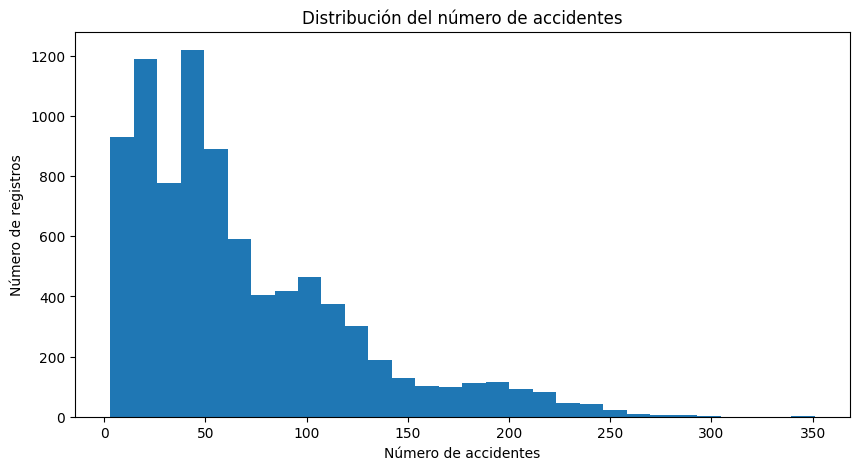

In [11]:
# Distribución del número de accidentes

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(dfNumerico["ACCIDENTES"].dropna(), bins=30)

plt.title("Distribución del número de accidentes")
plt.xlabel("Número de accidentes")
plt.ylabel("Número de registros")

plt.show()

Interpretación de la distribución del número de accidentes

La distribución del número de accidentes presenta un sesgo hacia la derecha. La mayor concentración de registros se encuentra en valores bajos y medios, aproximadamente entre 0 y 100 accidentes. A medida que aumenta el número de accidentes, disminuye la cantidad de registros, aunque se observan valores elevados que alcanzan aproximadamente 350 accidentes. Este comportamiento explica la diferencia observada entre la media (67,95) y la mediana (51).


# Distribución del costo de los servicios de taller

Este gráfico nos interesa bastante para AutoGest porque COSTO_TALLER representa el costo asociado a los servicios realizados en el taller.

Contexto breve:
Permite observar cómo se distribuyen los costos de los servicios de taller y si existen concentraciones o valores alejados del comportamiento general.

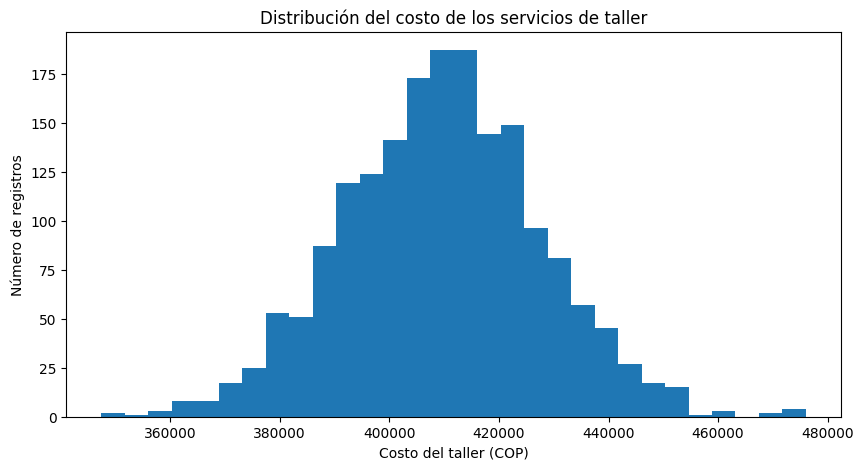

In [13]:

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(dfNumerico["COSTO_TALLER"].dropna(), bins=30)

plt.title("Distribución del costo de los servicios de taller")
plt.xlabel("Costo del taller (COP)")
plt.ylabel("Número de registros")

plt.show()

Interpretación de la distribución del costo de los servicios de taller


El costo de los servicios de taller presenta una distribución relativamente
concentrada. La media es de aproximadamente $409.655,62 COP y la mediana es
de $409.804,30 COP, valores muy cercanos entre sí. Esto indica que los costos
se encuentran distribuidos de manera relativamente equilibrada y que no se
observa una diferencia importante entre el valor promedio y el valor central.

# Distribución del número de evasores

Contexto breve:
Permite identificar cómo se distribuye el número de evasores y detectar posibles valores extremadamente altos.

En este caso utilizaremos un diagrama de caja (boxplot), porque nos permite visualizar mejor la mediana, la dispersión y los posibles valores atípicos.

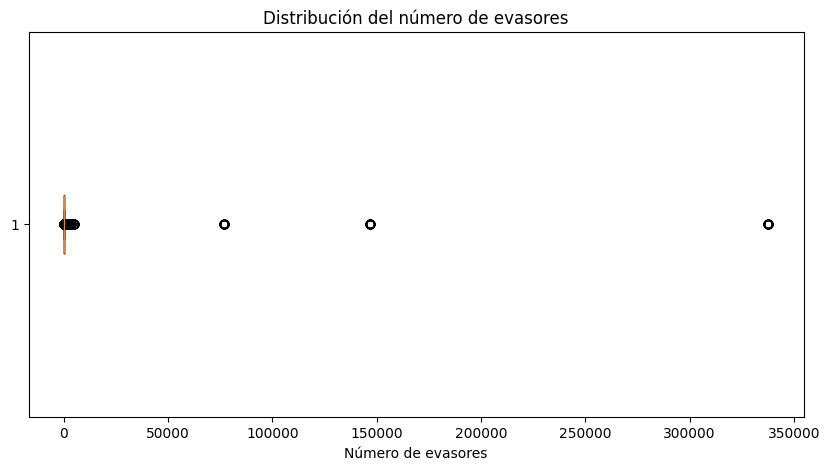

In [14]:

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.boxplot(dfNumerico["EVASORES"].dropna(), vert=False)

plt.title("Distribución del número de evasores")
plt.xlabel("Número de evasores")

plt.show()

Interpretación de la distribución del número de evasores

La variable EVASORES presenta una distribución fuertemente sesgada hacia
valores altos. La mediana es de 36 evasores, mientras que la media alcanza
aproximadamente 4.002 evasores y el valor máximo es de 337.792. Esta gran
diferencia indica la presencia de valores extremadamente altos que afectan
considerablemente el promedio. Estos registros deben conservarse para el
análisis mientras no exista evidencia de que correspondan a errores en los datos.


# Distribución del kilometraje promedio

Contexto breve:
Permite observar cómo se distribuye el kilometraje promedio de los vehículos registrados en los datos de taller.

Como el kilometraje es una medida continua, utilizaremos un histograma.

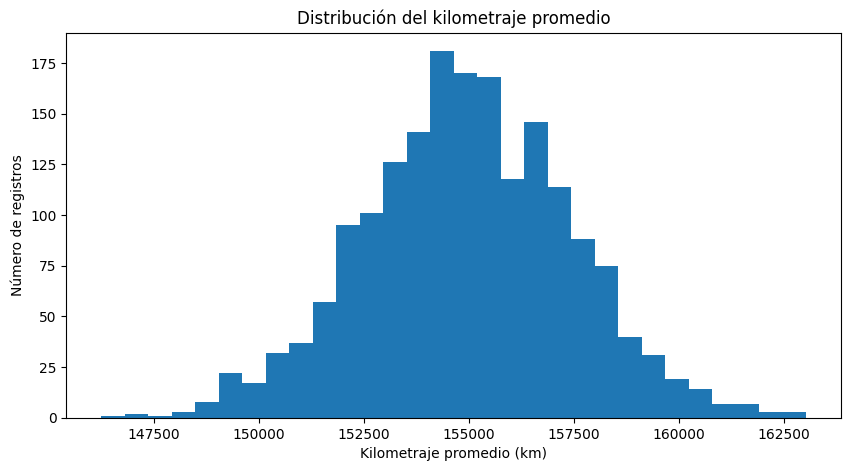

In [15]:

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(dfNumerico["KILOMETRAJE_PROMEDIO"].dropna(), bins=30)

plt.title("Distribución del kilometraje promedio")
plt.xlabel("Kilometraje promedio (km)")
plt.ylabel("Número de registros")

plt.show()

Interpretación de la distribución del kilometraje promedio


El kilometraje promedio presenta una distribución concentrada alrededor de los 155.000 km. La media (154.965,1 km) y la mediana (154.915,7 km) son muy similares, lo que indica que no existe una diferencia importante entre el valor central y el promedio. Los registros se encuentran aproximadamente entre 146.000 y 163.000 km, mostrando una variación moderada.

# Matriz de correlaciones entre variables numéricas

Contexto breve:
Permite identificar la dirección e intensidad de las relaciones lineales entre las variables numéricas del dataset.

In [ ]:


matrizCorrelacion = dfNumerico.corr(method="pearson")

matrizCorrelacion

,ACCIDENTES,SERVICIOS_TALLER,COSTO_TALLER,DURACION_PROMEDIO_TALLER,KILOMETRAJE_PROMEDIO,TRAFICO,EVASORES,EXENTOS,PEAJES,TARIFA_PROMEDIO
0,28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Los NaN que aparecen en el primer resultado son simplemente porque estamos mostrando dfNumerico.head(), no la matriz.

# Analisis matematico para identificar una relacion lineal importante entre las varibales 


In [13]:
dfNumerico.head()

,ACCIDENTES,SERVICIOS_TALLER,COSTO_TALLER,DURACION_PROMEDIO_TALLER,KILOMETRAJE_PROMEDIO,TRAFICO,EVASORES,EXENTOS,PEAJES,TARIFA_PROMEDIO
0,28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
dfNumerico.shape

(8613, 10)

In [15]:
matrizCorrelacion = dfNumerico.corr(method="pearson")

print(matrizCorrelacion)

                          ACCIDENTES  SERVICIOS_TALLER  COSTO_TALLER  \
ACCIDENTES                  1.000000         -0.012693     -0.035445   
SERVICIOS_TALLER           -0.012693          1.000000      0.665809   
COSTO_TALLER               -0.035445          0.665809      1.000000   
DURACION_PROMEDIO_TALLER    0.010756         -0.048028     -0.016879   
KILOMETRAJE_PROMEDIO       -0.018477         -0.017879     -0.024242   
TRAFICO                    -0.016663          0.001743     -0.007585   
EVASORES                   -0.042610         -0.010092     -0.001194   
EXENTOS                     0.333583          0.025367      0.023346   
PEAJES                     -0.056115         -0.006829     -0.015077   
TARIFA_PROMEDIO            -0.363794          0.026855      0.001332   

                          DURACION_PROMEDIO_TALLER  KILOMETRAJE_PROMEDIO  \
ACCIDENTES                                0.010756             -0.018477   
SERVICIOS_TALLER                         -0.048028     

La mayoría de las demás correlaciones están muy cerca de 0, por ejemplo:

ACCIDENTES ↔ SERVICIOS_TALLER       -0.0127
ACCIDENTES ↔ COSTO_TALLER           -0.0354
COSTO_TALLER ↔ DURACION              -0.0169
TRAFICO ↔ SERVICIOS_TALLER            0.0017

Eso significa que no encontramos una relación lineal importante entre esas variables.

In [16]:
dfNumerico.dtypes

ACCIDENTES                    int64
SERVICIOS_TALLER            float64
COSTO_TALLER                float64
DURACION_PROMEDIO_TALLER    float64
KILOMETRAJE_PROMEDIO        float64
TRAFICO                     float64
EVASORES                    float64
EXENTOS                     float64
PEAJES                      float64
TARIFA_PROMEDIO             float64
dtype: object

La relación más importante para AutoGest

La primera que yo destacaría es:

SERVICIOS_TALLER ↔ COSTO_TALLER

r = 0.6658

Es una correlación positiva moderada-fuerte.

# La relación más importante para AutoGest

1. La primera que yo destacaría es:
SERVICIOS_TALLER ↔ COSTO_TALLER

r = 0.6658
Es una correlación positiva moderada-fuerte.

Cuando aumenta la cantidad de servicios realizados en el taller, también tiende a aumentar el costo asociado a los servicios.

2. Segunda relación importante
PEAJES ↔ TARIFA_PROMEDIO

r = 0.6622

También es una correlación positiva moderada-fuerte.

Existe una relación positiva entre la cantidad de peajes y la tarifa promedio. A medida que aumentan los peajes registrados, también tiende a aumentar la tarifa promedio.

3. Relación accidentes–tarifa
ACCIDENTES ↔ TARIFA_PROMEDIO

r = -0.3638

Es una correlación negativa débil-moderada.

Esto significa:

Existe una tendencia inversa entre el número de accidentes y la tarifa promedio: cuando una variable aumenta, la otra tiende a disminuir.

4. Relación accidentes–exentos
ACCIDENTES ↔ EXENTOS

r = 0.3336

Es positiva, pero bastante menor que las dos primeras.

Podemos escribir:

Se observa una relación positiva débil-moderada entre los accidentes y los vehículos exentos. Esto indica que ambas variables tienden a aumentar conjuntamente en cierta medida, aunque la relación no es suficientemente fuerte para considerarla determinante.